# How Models Learn — a step-by-step, runnable notebook

A model starts out knowing **nothing**. This notebook shows, one operation at a time, exactly how it gets better — on **real data**, with a learning loop we build from scratch (no autodiff). It is the executable companion to the chapter and to `how_models_learn.py`; every function used here lives in that module, imported so the notebook and the module can never drift apart.

By the end you will have **watched**, on real datasets:

1. a model that **knows nothing** (a flat line) and how we score its wrongness with a **loss**;
2. the **gradient** — which way is downhill — and a single **gradient-descent step** by hand;
3. the **full training loop**: predict → loss → gradient → update → repeat, with the loss falling;
4. the fitted line **rotating into place**, and a proof it reaches the *exact* least-squares answer;
5. gradient descent as a **ball rolling downhill** on the real loss surface;
6. the **learning rate**: too small crawls, well-chosen converges, too large diverges;
7. the **same loop** training a **logistic-regression** classifier — a different loss, identical loop.

Everything runs on CPU in a couple of seconds, seeded for reproducibility.

## Step 0 — Setup and version banner

We import the real functions from the chapter module (so this notebook uses the *exact same code* the figures and the page use) and print the library versions the results were produced on.

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import sklearn

from how_models_learn import (
    load_income_price, predict_linear, mse_loss, mse_gradient,
    train_linear_gd, sklearn_linear, linear_gd_path, lr_sweep, LR_SWEEP,
    load_tumor_2d, sigmoid, log_loss_binary, log_loss_gradient,
    predict_proba, train_logistic_gd, sklearn_logistic,
)

print(f'numpy {np.__version__} | scikit-learn {sklearn.__version__} '
      f'| matplotlib {matplotlib.__version__}')

numpy 2.4.6 | scikit-learn 1.9.0 | matplotlib 3.10.9


## Step 1 — A model that knows nothing

Our model is the simplest possible: a straight line, $\hat y = w\,x + b$. Here $x$ is a California district's **median income** and $\hat y$ is our prediction of its **median house value**. Learning means finding good numbers for the **slope** $w$ and **intercept** $b$.

Before any learning we set $w = 0,\ b = 0$ — a flat line pinned at zero. It predicts a house value of 0 for *every* district, no matter the income. That is a model that knows nothing; watch how badly it does on real data.

In [2]:
reg = load_income_price()
print(f'{reg.x.size} real districts | feature: {reg.feature_name} | target: {reg.target_name}')

w, b = np.array([0.0]), 0.0            # the model that knows nothing
y_hat = predict_linear(reg.x[:, None], w, b)
print(f'first 5 predictions : {np.round(y_hat[:5], 2)}   (all zero — it ignores income)')
print(f'first 5 true values : {np.round(reg.y[:5], 2)}   ($100k units)')

2000 real districts | feature: median income (standardised) | target: median house value ($100k)
first 5 predictions : [0. 0. 0. 0. 0.]   (all zero — it ignores income)
first 5 true values : [1.74 2.25 0.62 1.66 1.78]   ($100k units)


## Step 2 — Measuring *how wrong*: the loss

To improve, the model first needs a number that says how wrong it is. That number is the **loss**. For regression we use the **mean squared error** — the average squared gap between prediction and truth:

$$L(w, b) = \frac{1}{n}\sum_{i=1}^{n}\big(\hat y_i - y_i\big)^2, \qquad \hat y_i = w\,x_i + b.$$

Squaring makes every error positive and punishes big misses far more than small ones. A perfect model has loss 0; our know-nothing model should have a big loss.

In [3]:
loss0 = mse_loss(reg.x[:, None], reg.y, w, b)
print(f'loss of the know-nothing model = {loss0:.4f}')
print('this is just the mean of y squared, since y_hat = 0:',
      round(float(np.mean(reg.y ** 2)), 4))
print('\nour whole job: make this number as small as the data allows.')

loss of the know-nothing model = 5.5775
this is just the mean of y squared, since y_hat = 0: 5.5775

our whole job: make this number as small as the data allows.


## Step 3 — Which way is downhill? The gradient

We want to change $w$ and $b$ to *lower* the loss. But which direction lowers it? Calculus answers this: the **gradient** $\nabla L = (\partial L/\partial w,\ \partial L/\partial b)$ is the direction of steepest **increase**. So the direction of steepest **decrease** — downhill — is the *negative* gradient. For our MSE, the chain rule gives a clean form (derived in the chapter):

$$\frac{\partial L}{\partial w} = \frac{2}{n}\sum_i (\hat y_i - y_i)\,x_i, \qquad \frac{\partial L}{\partial b} = \frac{2}{n}\sum_i (\hat y_i - y_i).$$

Both are built from the **residual** $\hat y_i - y_i$ (prediction minus truth). At our starting point the predictions are all 0, so every residual is $-y_i$ — the gradient will point us toward a positive slope and intercept, exactly as it should.

In [4]:
grad_w, grad_b = mse_gradient(reg.x[:, None], reg.y, w, b)
print(f'gradient at (w=0, b=0): dL/dw = {grad_w[0]:+.4f}, dL/db = {grad_b:+.4f}')
print('both negative -> downhill is +w, +b (raise the slope and intercept). Makes sense:')
print('the line is far too low, so lifting and tilting it up reduces the error.')

gradient at (w=0, b=0): dL/dw = -1.5638, dL/db = -4.1435
both negative -> downhill is +w, +b (raise the slope and intercept). Makes sense:
the line is far too low, so lifting and tilting it up reduces the error.


## Step 4 — One gradient-descent step, by hand

Now the single most important line in machine learning. We nudge each parameter a small amount in the downhill (negative-gradient) direction:

$$w \leftarrow w - \eta\,\frac{\partial L}{\partial w}, \qquad b \leftarrow b - \eta\,\frac{\partial L}{\partial b}.$$

The number $\eta$ (**eta**) is the **learning rate** — how big a step we take. Let's take one step with $\eta = 0.3$ and confirm the loss goes **down**.

In [5]:
eta = 0.3
w_new = w - eta * grad_w
b_new = b - eta * grad_b
loss1 = mse_loss(reg.x[:, None], reg.y, w_new, b_new)
print(f'before: w={w[0]:+.3f}, b={b:+.3f}, loss={loss0:.4f}')
print(f'after : w={w_new[0]:+.3f}, b={b_new:+.3f}, loss={loss1:.4f}')
print(f'loss dropped by {loss0 - loss1:.4f} in a single step. Now just repeat.')

before: w=+0.000, b=+0.000, loss=5.5775
after : w=+0.469, b=+1.243, loss=1.4586
loss dropped by 4.1189 in a single step. Now just repeat.


## Step 5 — The full training loop: predict → loss → gradient → update → repeat

Learning is that one step, done over and over. Each full pass is an **epoch**. `train_linear_gd` runs the loop from $w=0, b=0$ for 200 epochs, recording the loss each time. Watch it fall steeply at first (the gradient is large when we're very wrong) and then flatten as it approaches the best possible fit.

loss at epoch 0   = 5.5775  (knows nothing)
loss at epoch 5   = 0.6746  (already most of the way)
loss at epoch 200 = 0.6741  (converged)


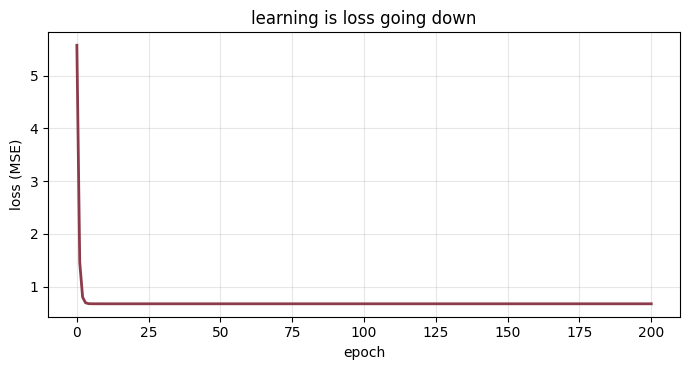

In [6]:
fit = train_linear_gd(reg.x, reg.y)
curve = fit.loss_curve
print(f'loss at epoch 0   = {curve[0]:.4f}  (knows nothing)')
print(f'loss at epoch 5   = {curve[5]:.4f}  (already most of the way)')
print(f'loss at epoch 200 = {curve[-1]:.4f}  (converged)')

plt.figure(figsize=(7, 3.8))
plt.plot(range(curve.size), curve, lw=2, color='#8B3B4A')
plt.xlabel('epoch')
plt.ylabel('loss (MSE)')
plt.title('learning is loss going down')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Step 6 — Watch the line fit itself to the data

The falling loss *is* the line rotating into place. We froze $(w, b)$ at a few epochs during training; plotting each one over the real scatter shows the model physically fitting itself — from the flat know-nothing line at epoch 0 to the best straight-line fit by epoch 200.

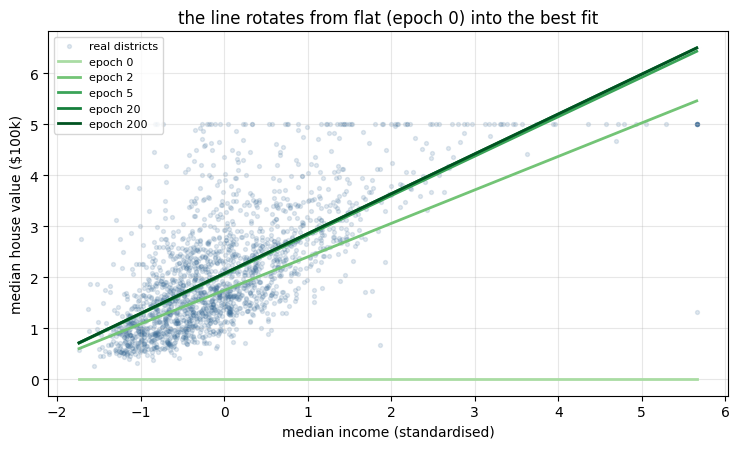

In [7]:
xs = np.linspace(reg.x.min(), reg.x.max(), 100)
plt.figure(figsize=(7.5, 4.6))
plt.scatter(reg.x, reg.y, s=8, alpha=0.15, color='#3A6B96', label='real districts')
shades = plt.cm.Greens(np.linspace(0.35, 0.95, len(fit.snapshots)))
for shade, epoch in zip(shades, sorted(fit.snapshots)):
    ws, bs = fit.snapshots[epoch]
    plt.plot(xs, ws[0] * xs + bs, color=shade, lw=2, label=f'epoch {epoch}')
plt.xlabel(reg.feature_name)
plt.ylabel(reg.target_name)
plt.title('the line rotates from flat (epoch 0) into the best fit')
plt.legend(fontsize=8, loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Step 7 — We built the real thing: it matches scikit-learn

Is our from-scratch gradient descent *actually correct*, or just close? Linear regression has a known closed-form answer — the **least-squares** solution — which `sklearn.LinearRegression` computes directly (no gradient descent at all). If our GD found the same slope and intercept, we didn't build a lookalike; we built the real algorithm and it converged to the exact right answer.

In [8]:
sk_w, sk_b = sklearn_linear(reg.x, reg.y)
print(f'our gradient descent : slope w = {fit.w[0]:+.5f}, intercept b = {fit.b:+.5f}')
print(f'sklearn least squares: slope w = {sk_w[0]:+.5f}, intercept b = {sk_b:+.5f}')
print('match within 1e-2:', bool(np.allclose(fit.w, sk_w, atol=1e-2)
                                 and np.isclose(fit.b, sk_b, atol=1e-2)))
print('\n=> our loop reached the provably-optimal fit. It is the real thing.')

our gradient descent : slope w = +0.78188, intercept b = +2.07174
sklearn least squares: slope w = +0.78188, intercept b = +2.07174
match within 1e-2: True

=> our loop reached the provably-optimal fit. It is the real thing.


## Step 8 — Gradient descent is a ball rolling downhill

Here is the picture behind the whole method. The loss $L(w, b)$ is a **surface** over the two parameters — a bowl. Gradient descent drops a ball at our start $(0, 0)$ and lets it roll downhill, one step per epoch, until it settles at the bottom — the least-squares minimum (the star). We plot the real surface and the real path our training took.

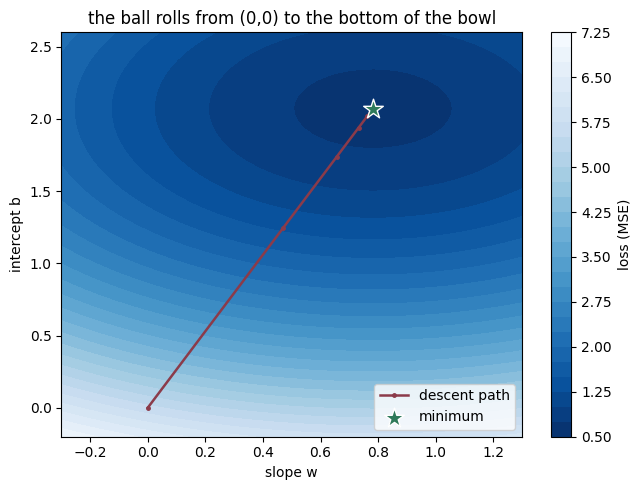

In [9]:
w_hist, b_hist, _ = linear_gd_path(reg.x, reg.y)

# evaluate the real loss surface on a grid around the descent path
wg = np.linspace(-0.3, 1.3, 60)
bg = np.linspace(-0.2, 2.6, 60)
WW, BB = np.meshgrid(wg, bg)
Z = np.array([[mse_loss(reg.x[:, None], reg.y, np.array([w_]), b_)
               for w_ in wg] for b_ in bg])

plt.figure(figsize=(6.6, 5))
cs = plt.contourf(WW, BB, Z, levels=25, cmap='Blues_r')
plt.colorbar(cs, label='loss (MSE)')
plt.plot(w_hist, b_hist, color='#8B3B4A', lw=1.8, marker='o', ms=2.5, label='descent path')
plt.scatter([sk_w[0]], [sk_b], color='#2E7A5A', marker='*', s=220,
            edgecolor='white', zorder=5, label='minimum')
plt.xlabel('slope w')
plt.ylabel('intercept b')
plt.title('the ball rolls from (0,0) to the bottom of the bowl')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Step 9 — The learning rate decides everything

The step size $\eta$ is the hyperparameter you *must* get roughly right. Same model, same data — only $\eta$ changes:

* **too small** ($\eta = 0.001$): steps are tiny, the loss barely moves — it **crawls**;
* **well-chosen** ($\eta = 0.3$): steps are just right, the loss plunges — it **converges**;
* **too large** ($\eta = 1.02$): steps overshoot the minimum and grow — it **diverges** to infinity.

We measure all three on the real regression (note the log scale — the diverging run climbs off the top).

lr = 0.001 : start 5.578 -> end 4.530
lr = 0.3   : start 5.578 -> end 0.674
lr = 1.02  : start 5.578 -> end 543.304


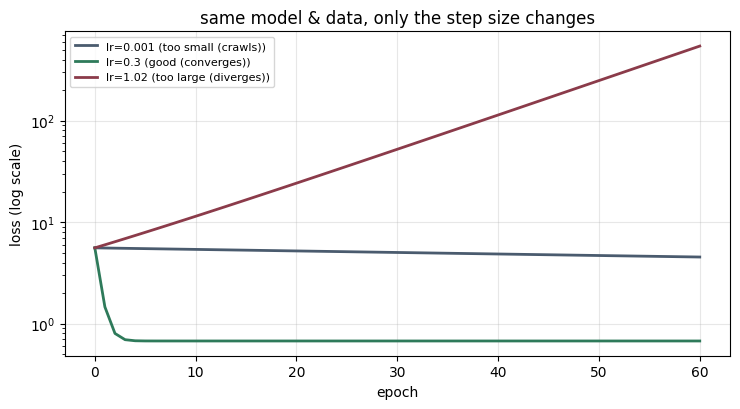

In [10]:
curves = lr_sweep(reg.x, reg.y)
for rate in LR_SWEEP:
    c = curves[rate]
    end = 'inf' if not np.isfinite(c[-1]) else f'{c[-1]:.3f}'
    print(f'lr = {rate:<6}: start {c[0]:.3f} -> end {end}')

plt.figure(figsize=(7.5, 4.2))
labels = {LR_SWEEP[0]: 'too small (crawls)', LR_SWEEP[1]: 'good (converges)',
          LR_SWEEP[2]: 'too large (diverges)'}
colors = {LR_SWEEP[0]: '#4A5B6E', LR_SWEEP[1]: '#2E7A5A', LR_SWEEP[2]: '#8B3B4A'}
for rate in LR_SWEEP:
    c = np.clip(np.nan_to_num(curves[rate], posinf=1e6), 1e-3, 1e6)
    plt.plot(range(c.size), c, lw=2, color=colors[rate], label=f'lr={rate} ({labels[rate]})')
plt.yscale('log')
plt.xlabel('epoch')
plt.ylabel('loss (log scale)')
plt.title('same model & data, only the step size changes')
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Step 10 — The same loop, a different loss: classification

Does this loop only work for drawing lines through scatter plots? No — it is *how every model learns*. To prove it, we switch problems entirely: **classifying** real tumours as benign or malignant from two measurements (mean radius, mean texture). Two things change, the loop does not:

* the model now outputs a **probability** via the **sigmoid**, $p = \sigma(w\!\cdot\!x + b) = 1/(1+e^{-(w\cdot x + b)})$, squashing any score into $[0, 1]$;
* the loss becomes **log-loss** (binary cross-entropy), the *surprise* of the true label: $L = -\frac{1}{n}\sum_i [\,y_i \log p_i + (1-y_i)\log(1-p_i)\,]$.

(The chapter on Cross-Entropy & KL derives this loss in full.) A know-nothing classifier predicts $p=0.5$ for everyone, giving loss $\ln 2 \approx 0.693$ — a coin flip.

In [11]:
cls = load_tumor_2d()
print(f'{cls.x.shape[0]} real tumours | features: {cls.feature_names}')
print(f'class balance: {int((cls.y == 1).sum())} benign, {int((cls.y == 0).sum())} malignant')

w0, b0 = np.zeros(2), 0.0                       # know-nothing classifier
print(f'sigmoid(0) = {sigmoid(np.array([0.0]))[0]:.3f}  (predicts 0.5 for everyone)')
print(f'log-loss of the coin-flip model = {log_loss_binary(cls.x, cls.y, w0, b0):.4f} '
      f'(= ln 2 = {np.log(2):.4f})')

400 real tumours | features: ('mean radius (std)', 'mean texture (std)')
class balance: 259 benign, 141 malignant
sigmoid(0) = 0.500  (predicts 0.5 for everyone)
log-loss of the coin-flip model = 0.6931 (= ln 2 = 0.6931)


## Step 11 — Train the classifier with the *identical* loop

`train_logistic_gd` is the same four steps — predict, measure loss, compute gradient, step downhill — with the sigmoid model and the log-loss. Watch the loss fall from $\ln 2$ just like the MSE fell, and read off the final training accuracy.

log-loss at epoch 0    = 0.6931  (= ln 2, a coin flip)
log-loss at epoch 2000 = 0.2323  (converged)
final training accuracy = 0.890


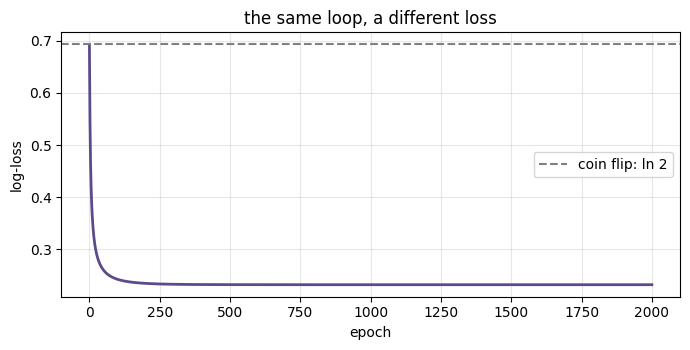

In [12]:
lfit = train_logistic_gd(cls.x, cls.y)
lcurve = lfit.loss_curve
acc = float(np.mean((predict_proba(cls.x, lfit.w, lfit.b) >= 0.5).astype(int) == cls.y))
print(f'log-loss at epoch 0    = {lcurve[0]:.4f}  (= ln 2, a coin flip)')
print(f'log-loss at epoch 2000 = {lcurve[-1]:.4f}  (converged)')
print(f'final training accuracy = {acc:.3f}')

plt.figure(figsize=(7, 3.6))
plt.plot(range(lcurve.size), lcurve, lw=2, color='#5D4A8A')
plt.axhline(np.log(2), ls='--', color='gray', label='coin flip: ln 2')
plt.xlabel('epoch')
plt.ylabel('log-loss')
plt.title('the same loop, a different loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Step 12 — The gradient is the *same shape* as before

Why does the identical loop work for a completely different loss? Because the gradient of log-loss, after the sigmoid derivative and the log cancel, collapses to the very same form as MSE's:

$$\frac{\partial L}{\partial w} = \frac{1}{n}\sum_i (p_i - y_i)\,x_i, \qquad \frac{\partial L}{\partial b} = \frac{1}{n}\sum_i (p_i - y_i).$$

It is **prediction minus target** again — exactly the residual structure from Step 3. That is the deep reason one gradient-descent loop trains linear regression, logistic regression, and (with a softmax) the output layer of a neural network alike.

In [13]:
gw, gb = log_loss_gradient(cls.x, cls.y, w0, b0)
p0 = predict_proba(cls.x, w0, b0)
manual_gw = (cls.x.T @ (p0 - cls.y)) / cls.x.shape[0]   # (1/n) X^T (p - y), by hand
print(f'log_loss_gradient dL/dw = {np.round(gw, 4)}')
print(f'by-hand (1/n)Xᵀ(p - y) = {np.round(manual_gw, 4)}')
print('same (p - y) structure as linear regression:', bool(np.allclose(gw, manual_gw)))

log_loss_gradient dL/dw = [0.3536 0.1833]
by-hand (1/n)Xᵀ(p - y) = [0.3536 0.1833]
same (p - y) structure as linear regression: True


## Step 13 — And it matches scikit-learn's classifier

The same proof as Step 7, for classification: our from-scratch logistic GD should reach the same weights as `sklearn.LogisticRegression` (fit almost unregularised, so it targets the same maximum-likelihood solution).

In [14]:
lw, lb = sklearn_logistic(cls.x, cls.y)
print(f'our GD    : w = {np.round(lfit.w, 3)}, b = {lfit.b:+.3f}')
print(f'sklearn   : w = {np.round(lw, 3)}, b = {lb:+.3f}')
print('match within 5e-2:', bool(np.allclose(lfit.w, lw, atol=5e-2)
                                 and np.isclose(lfit.b, lb, atol=5e-2)))

our GD    : w = [-4.298 -0.841], b = +0.984
sklearn   : w = [-4.296 -0.84 ], b = +0.984
match within 5e-2: True


## Step 14 — The decision boundary sharpening

For classification, the visual payoff isn't a fitted line through points — it's the **decision boundary**: the line where the model is 50/50 ($p = 0.5$, i.e. $w\!\cdot\!x + b = 0$). As training lowers the loss, that boundary swings into the place that best separates benign from malignant. We plot the frozen boundaries from early to late training.

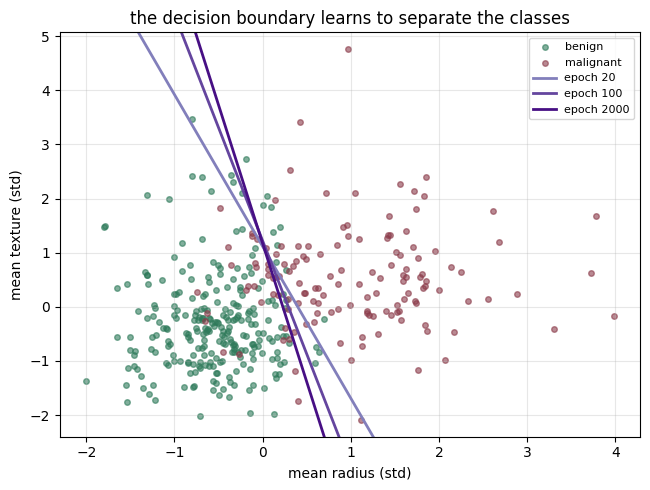

In [15]:
benign = cls.y == 1
xlim = (cls.x[:, 0].min() - 0.3, cls.x[:, 0].max() + 0.3)
plt.figure(figsize=(6.6, 5))
plt.scatter(cls.x[benign, 0], cls.x[benign, 1], s=16, color='#2E7A5A', alpha=0.6, label='benign')
plt.scatter(cls.x[~benign, 0], cls.x[~benign, 1], s=16, color='#8B3B4A', alpha=0.6, label='malignant')
shades = plt.cm.Purples(np.linspace(0.45, 0.95, len(lfit.snapshots)))
gx = np.array(xlim)
for shade, epoch in zip(shades, sorted(lfit.snapshots)):
    ws, bs = lfit.snapshots[epoch]
    if abs(ws[1]) < 1e-6:
        continue                                   # epoch-0 boundary is undefined (w=0)
    plt.plot(gx, -(ws[0] * gx + bs) / ws[1], color=shade, lw=2, label=f'epoch {epoch}')
plt.xlim(*xlim)
plt.ylim(cls.x[:, 1].min() - 0.3, cls.x[:, 1].max() + 0.3)
plt.xlabel(cls.feature_names[0])
plt.ylabel(cls.feature_names[1])
plt.title('the decision boundary learns to separate the classes')
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Recap

In one runnable notebook, on real data, we saw the whole of how a model learns:

| Step | What we did | The takeaway |
|---|---|---|
| 1–2 | a flat know-nothing line; its MSE | a **loss** scores how wrong the model is |
| 3–4 | the gradient; one step by hand | the **negative gradient** points downhill; one step lowers loss |
| 5–6 | the full loop; the line fitting | learning = repeating the step; loss falls, the line rotates in |
| 7 | match `sklearn` least squares | our from-scratch GD reaches the **provably-optimal** fit |
| 8 | the loss surface + path | gradient descent = **a ball rolling downhill** |
| 9 | crawl / converge / diverge | the **learning rate** is the step size you must get right |
| 10–14 | logistic regression, same loop | a different model & loss, the **identical loop** — matched to `sklearn` |

One loop — **predict → measure the loss → follow the gradient downhill → repeat** — trains everything from this two-parameter line to a trillion-parameter language model. Only the model and the loss change; the loop is always the same. That is how models learn.